Run the cell below once to install the required packages (skip if you've already run `pip install -r requirements.txt` locally).

In [1]:
# pip install -r requirements.txt

Run the cell below once to unzip the results folder (only with Google Colab)

In [2]:
# !unzip //content/results.zip -d /content/ 

In [3]:
import pandas as pd
import os
from pathlib import Path

from IPython.display import Markdown, display
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
 
repo_dir = os.getcwd() #replace this with your local path 
if repo_dir not in sys.path:
    sys.path.append(repo_dir)

### Audits and Smart Contracts

In [4]:
df_audit = pd.read_excel(os.path.join(repo_dir, "audit_dataset.xlsx"))
df_audit = df_audit.dropna(how="all")
df_audit

,Audit,Auditor,Link,Date,Issue ID,Score,MEV,Limitation,Fix,Source Code,Source Code Link
0,zkevmbridg,Trail of bits,https://github.com/trailofbits/publications/bl...,2023-12-01,1,medium,NO,1.2,YES,NO,NaN
1,BeethovenX,Trail of bits,https://github.com/trailofbits/publications/bl...,2022-02-01,na,na,YES,NaN,NF,YES,no repo
2,paxos-paypal-pyusd,Trail of bits,https://github.com/trailofbits/publications/bl...,2023-01-01,2,low,NO,1.2,YES,NO,NaN
3,paxos-paypal-pyusd,Trail of bits,https://github.com/trailofbits/publications/bl...,2023-01-01,10,low,YES,NaN,NO,NO,NaN
4,CurveDAO,Trail of bits,https://github.com/trailofbits/publications/bl...,2020-07-01,14,minor,YES,NaN,NF,NO,NaN
...,...,...,...,...,...,...,...,...,...,...,...
389,PEAKDEFI,Quantstamp,https://certificate.quantstamp.com/full/peakde...,2020-11-01,QSP-12,low,NO,2.0,YES,NF,NaN
390,Multis,Quantstamp,https://certificate.quantstamp.com/full/multis...,2020-04-01,QSP-5,informational,NO,2.0,NO,YES,https://github.com/multis/MULTISig
391,Acid - DigixDAO Dissolution Contract,Quantstamp,https://certificate.quantstamp.com/full/acid-d...,2020-02-01,QSP-6,low,NO,2.0,PARTIAL,YES,https://github.com/DigixGlobal/acid-solidity
392,Authereum,Quantstamp,https://certificate.quantstamp.com/full/auther...,2020-02-01,QSP-3,low,NO,1.0,NO,NF,https://github.com/token-mint/ngnt


In [5]:
# Counts the number of vulns x auditor (Table 1 in paper)

auditors = df_audit["Auditor"].unique()

print("Auditor x Vulns:")

header =  "| Auditor | #D_full | #D_aval | #D_fixes |\n"
sep = "| --- | --- | --- | --- |\n"

top = header + sep

total_x = 0
total_y = 0
total_z = 0
for auditor in auditors:
    row = []
    x = len(df_audit[ df_audit["Auditor"]==auditor]) 
    y = len(df_audit[(df_audit["Auditor"]==auditor) & (df_audit["Source Code"]=="YES") & (df_audit["Fix"]=="YES") ])
    z = y
    total_x += x
    total_y += y
    total_z += z
    row.append(f"{x}")
    row.append(f"{y}")
    row.append(f"{z}")
    line = "|"+f"{auditor} | "+" | ".join(row)+ "|\n"
    top= top + line
end_line = "| total | " + f"{total_x} | {total_y} | {total_z} |\n"
top = top + end_line

display(Markdown(top))


Auditor x Vulns:


| Auditor | #D_full | #D_aval | #D_fixes |
| --- | --- | --- | --- |
|Trail of bits | 81 | 2 | 2|
|Consensys Diligence | 79 | 11 | 11|
|Nethermind | 11 | 4 | 4|
|RuntimeVerification | 20 | 0 | 0|
|HashEx | 35 | 0 | 0|
|OpenZeppelin | 65 | 6 | 6|
|Hacken | 37 | 0 | 0|
|Quantstamp | 65 | 1 | 1|
| total | 393 | 24 | 24 |


### MEV analysis

In [6]:
# Results from MEV analysis (claim 2, Section 2.2.3)

tot_vuln = total_x

no_mev = len(df_audit[df_audit["MEV"]=="NO"])
no_mev_ev = len(df_audit[(df_audit["MEV"]=="NO") & (df_audit["Limitation"]==1)])
no_mev_non_mon = len(df_audit[(df_audit["MEV"]=="NO") & (df_audit["Limitation"]==2)])
no_mon_ev_non_mon = len(df_audit[(df_audit["MEV"]=="NO") & (df_audit["Limitation"]==1.2)])
perc_no_mev = no_mev / tot_vuln * 100
perc_no_mev_1 = no_mev_ev / tot_vuln * 100
perc_no_mev_2 = no_mev_non_mon / tot_vuln * 100
perc_no_mev_1_2 = no_mon_ev_non_mon / tot_vuln * 100

print("MEV Analysis:")

header =  "| Total | Not MEV | Not MEV (Eventual) | Not MEV (Non-monetary) | Not MEV (Eventual + Non-monetary) |\n"
sep = "| --- | --- | --- | --- | --- |\n"
line = f"| {tot_vuln} | {perc_no_mev} | {perc_no_mev_1} | {perc_no_mev_2} | {perc_no_mev_1_2} |\n"

top = header + sep + line

display(Markdown(top))


MEV Analysis:


| Total | Not MEV | Not MEV (Eventual) | Not MEV (Non-monetary) | Not MEV (Eventual + Non-monetary) |
| --- | --- | --- | --- | --- |
| 393 | 55.216284987277355 | 18.575063613231553 | 21.882951653944023 | 14.75826972010178 |


#### Vulnerabilities Classification Based on Audits' scores (Fig. 4 in paper)

In [7]:
# ===================
plt.rc('font', size=18)          # controls default text sizes
plt.rc('axes', titlesize=18)     # fontsize of the axes title
plt.rc('axes', labelsize=18)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=18)    # fontsize of the tick labels
plt.rc('ytick', labelsize=18)    # fontsize of the tick labels
plt.rc('legend', fontsize=16)    # legend fontsize
plt.rc('figure', titlesize=18)  # fontsize of the figure title
# ===================

In [ ]:
data = {}

x_labels = {'Not_MEV':'Total', 'Eventual':'Eventual', 'Non-monetary':'Non-monetary', 'eventual_non_monetary':'Eventual\nand Non-monetary'}

## mapping of scores in df_audit["Score"].unique() to labels
y_labels = {"Not Specified":["na", "not specified", "undetermined"], "Low / Minor":["low", "minor", "notes", "risks", "informational"], "Medium":["medium"], "High / Major":["high", "major"], "Critical":["critical"]}

color_scheme = {"Not Specified":"white", "Low / Minor":'gainsboro', "Medium":'silver', "High / Major":'darkgrey', "Critical":'dimgray'}
hatch_scheme = {"Not Specified":('xxx', 'silver'), "Low / Minor":('', 'silver'), "Medium":('/', 'darkgrey'), "High / Major":('///', 'dimgray'), "Critical":('///', 'black')}

for score in df_audit["Score"].unique():
    if(score is not np.nan):
        data[score] = {}
        data[score]["Total"] = len(df_audit[df_audit["Score"]==score])
        data[score]["Not_MEV"] = len(df_audit[(df_audit["Score"]==score) & (df_audit["MEV"]=="NO")])
        data[score]["Eventual"] = len(df_audit[(df_audit["Score"]==score) & (df_audit["Limitation"]==1)])
        data[score]["Non-monetary"] = len(df_audit[(df_audit["Score"]==score) & (df_audit["Limitation"]==2)])
        data[score]["eventual_non_monetary"] = len(df_audit[(df_audit["Score"]==score) & (df_audit["Limitation"]==1.2)])


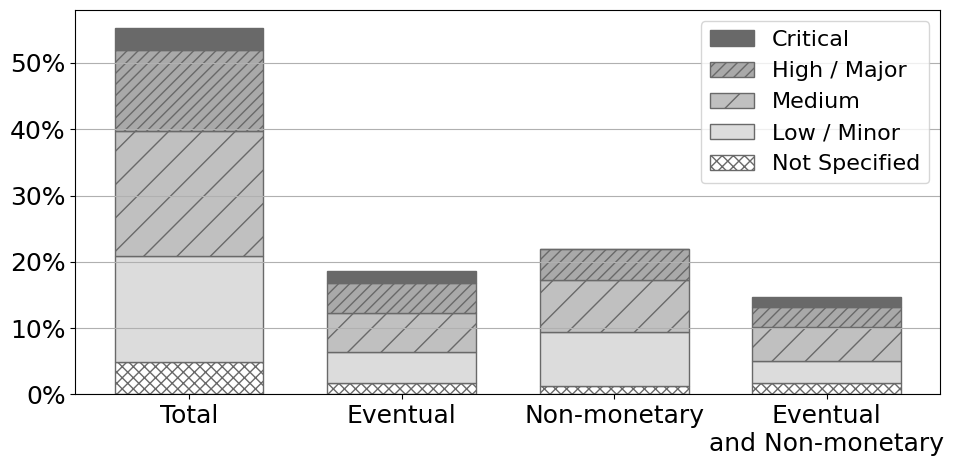

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

cases = x_labels.keys()
scores = y_labels.keys()

bottom = np.zeros(len(cases))
total_nmb = tot_vuln

values = {}
for s in scores:
    values[s] = np.array([np.sum([data[sub_s][c] for sub_s in y_labels[s]]) * 100/total_nmb for c in cases])


for boolean, v in values.items():
    p = ax.bar(list(x_labels.values()), v, 0.7, color=color_scheme[boolean], hatch=hatch_scheme[boolean][0], edgecolor='dimgrey', label=boolean, bottom=bottom)
    bottom += v

handles, labels = plt.gca().get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc="upper right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.grid(axis='y')

plt.tight_layout()
plt.savefig("./fig_severity_scores.pdf")
plt.show()

### Nyx & Sailfish Results

In [10]:
# import dataset of contracts

repo_dir = os.getcwd()  #replace this with your local path 

df_contracts = pd.read_excel(os.path.join(repo_dir, "contracts_dataset.xlsx"))
df_contracts

,Contract,Audit,Auditor,Issue ID,Event of interest,Function 1,Function 2,MEV,Limitations
0,AgentRegistryCore,https://diligence.consensys.io/audits/2022/11/...,consensys,5.5,"DebugCreateAgent(address owner, uint256 agentI...",createAgent,createAgent,NO,1.2
1,BatchedBancorMarketMaker,https://diligence.consensys.io/audits/2019/11/...,consensys,6.2,ClaimSellOrder(...),claimSellOrder,claimSellOrder,YES,NaN
2,ETHRegistrarController,https://consensys.io/diligence/audits/2019/03/...,consensys,3.3,NameRegistered(...);,commit,register,YES,NaN
3,Funds,https://github.com/ConsenSysDiligence/atomic-l...,consensys,6.15,DebugSetLoans(bool on),setLoans,setLoans,NO,1.2
4,KeepRandomBeaconOperator,https://diligence.consensys.io/audits/2020/02/...,consensys,5.7,DebugUnauthorizedSigningReported(...),reportUnauthorizedSigning,reportUnauthorizedSigning,NO,1.0
5,Loans,https://github.com/ConsenSysDiligence/atomic-l...,consensys,6.16,event DebugPull(...),pull,pull,NO,1.2
6,Pool,https://diligence.consensys.io/audits/2023/05/...,consensys,3.9,DebugBuy(uint256 weeklyPremium),addPolicy/setPolicy,buy,NO,1.0
7,RocketStorage,https://diligence.consensys.io/audits/2021/04/...,consensys,6.5,DebugInitialised(..),setBool,setBool,NO,1.2
8,RocketTokenRPL,https://consensys.io/diligence/audits/2021/04/...,consensys,6.9,"RPLInflationLog(msg.sender, newTokens, inflati...",inflationMintTokens,inflationMintTokens,YES,NaN
9,TransactionManager,https://diligence.consensys.io/audits/2022/11/...,consensys,5.5,TransactionPrepared(...),prepare,prepare,NO,1.2


In [11]:
# count the number of MEV / not MEV (and limitations) contracts in the dataset (vulnerable only)

df_vulnerable = df_contracts[~df_contracts["Contract"].str.contains("_fix")]
limitations = df_vulnerable["Limitations"]
is_no_mev = df_vulnerable["MEV"] == "NO"

tot_contracts = len(df_vulnerable)
mev = (df_vulnerable["MEV"] == "YES").sum()
no_mev = is_no_mev.sum()
no_mev_1 = (is_no_mev & (limitations == 1)).sum()
no_mev_2 = (is_no_mev & (limitations == 2)).sum()
no_mev_1_2 = (is_no_mev & (limitations == 1.2)).sum()

print("MEV vs Not MEV (contracts dataset, vulnerable only):")

header = "| Total | MEV | Not MEV | Not MEV (Eventual) | Not MEV (Non-Monetary) | Not MEV (Eventual + Non-monetary) |\n"
sep = "| --- | --- | --- | --- | --- | --- |\n"
line = f"| {tot_contracts} | {mev} | {no_mev} | {no_mev_1} | {no_mev_2} | {no_mev_1_2} |\n"

top = header + sep + line

display(Markdown(top))

MEV vs Not MEV (contracts dataset, vulnerable only):


| Total | MEV | Not MEV | Not MEV (Eventual) | Not MEV (Non-Monetary) | Not MEV (Eventual + Non-monetary) |
| --- | --- | --- | --- | --- | --- |
| 24 | 4 | 20 | 4 | 9 | 7 |


In [12]:
# summarize results
repo_root = os.getcwd() + ""  #replace this with your local path
if repo_root not in sys.path:
    sys.path.append(repo_root)

import summarize_nyx_results as snr
import summarize_sailfish_results as ssr

summary_nyx = snr.summarize()
summary_sailfish = ssr.summarize()

In [13]:
# Nyx:

TP = FP = FN = TN = 0
vulnerable_failures = 0
vulnerable_total = 0
TP_contracts = []
FP_contracts = []
FN_contracts = []
TN_contracts = []

expected_pairs = {}
for key in summary_nyx.keys():
    match = df_contracts[df_contracts['Contract'] == key]
    if match.empty:
        continue
    expected_pairs[key] = (match['Function 1'].values[0], match['Function 2'].values[0])
    func1, func2 = expected_pairs[key]

    is_fix = "_fix" in key
    result = summary_nyx[key]

    if not is_fix:
        vulnerable_total += 1

    # error means Nyx produced no function pairs at all for this contract
    if result == "error":
        if not is_fix:
            vulnerable_failures += 1
        continue

    if snr.pair_matches(func1, func2, result):
        if not is_fix:
            TP += 1
            TP_contracts.append(key)
        else:
            FP += 1
            FP_contracts.append(key)
    else:
        if not is_fix:
            FN += 1
            FN_contracts.append(key)
        else:
            TN += 1
            TN_contracts.append(key)

failure_rate = vulnerable_failures / vulnerable_total * 100 if vulnerable_total else 0
print()
print(f"Failure rate (vulnerable contracts): {vulnerable_failures}/{vulnerable_total} ({failure_rate:.1f}%)")
#print(f"TP={TP} FP={FP} FN={FN} TN={TN}")

# Breakdown of Nyx detections (TP) by MEV category, vulnerable contracts only
detected = set(TP_contracts)

def count_detected(mask):
    contracts = set(df_vulnerable.loc[mask, "Contract"])
    return len(contracts & detected), len(contracts)

categories = [
    ("MEV", df_vulnerable["MEV"] == "YES"),
    ("Not MEV (1)", is_no_mev & (limitations == 1)),
    ("Not MEV (2)", is_no_mev & (limitations == 2)),
    ("Not MEV (1,2)", is_no_mev & (limitations == 1.2)),
]

print()
print("Nyx detection rate by MEV category (vulnerable contracts):")

header = "| Category | Detected | Total | Detection Rate | Failure Rate |\n"
sep = "| --- | --- | --- | --- | --- |\n"
top = header + sep
for label, mask in categories:
    d, t = count_detected(mask)
    rate = f"{(d / t * 100):.1f}%" if t else "N/A"
    failure_rate = (1 - (d / t))*100 if t else 0
    top += f"| {label} | {d} | {t} | {rate} | {failure_rate:.1f}% |\n"

display(Markdown(top))


Failure rate (vulnerable contracts): 5/24 (20.8%)

Nyx detection rate by MEV category (vulnerable contracts):


| Category | Detected | Total | Detection Rate | Failure Rate |
| --- | --- | --- | --- | --- |
| MEV | 1 | 4 | 25.0% | 75.0% |
| Not MEV (1) | 0 | 4 | 0.0% | 100.0% |
| Not MEV (2) | 1 | 9 | 11.1% | 88.9% |
| Not MEV (1,2) | 0 | 7 | 0.0% | 100.0% |


In [14]:
# Sailfish:

TP = FP = FN = TN = 0
vulnerable_failures = 0
vulnerable_total = 0
TP_contracts = []
FP_contracts = []
FN_contracts = []
TN_contracts = []

expected_pairs = {}
for key in summary_sailfish.keys():
    match = df_contracts[df_contracts['Contract'] == key]
    if match.empty:
        continue
    expected_pairs[key] = (match['Function 1'].values[0], match['Function 2'].values[0])
    func1, func2 = expected_pairs[key]

    is_fix = "_fix" in key
    result = summary_sailfish[key]

    if not is_fix:
        vulnerable_total += 1

    # error means Sailfish failed to produce a result at all for this contract
    if result == "error":
        if not is_fix:
            vulnerable_failures += 1
        continue

    # not_detected means Sailfish ran but found no vulnerable pair: TN for fixes, FN for vulnerable
    if result == "not_detected":
        if not is_fix:
            FN += 1
            FN_contracts.append(key)
        else:
            TN += 1
            TN_contracts.append(key)
        continue

    if snr.pair_matches(func1, func2, result):
        if not is_fix:
            TP += 1
            TP_contracts.append(key)
        else:
            FP += 1
            FP_contracts.append(key)
    else:
        if not is_fix:
            FN += 1
            FN_contracts.append(key)
        else:
            TN += 1
            TN_contracts.append(key)

failure_rate = vulnerable_failures / vulnerable_total * 100 if vulnerable_total else 0
print()
print(f"Failure rate (vulnerable contracts): {vulnerable_failures}/{vulnerable_total} ({failure_rate:.1f}%)")

# breakdown of Sailfish detections (TP) by MEV category, vulnerable contracts only
detected = set(TP_contracts)

def count_detected(mask):
    contracts = set(df_vulnerable.loc[mask, "Contract"])
    return len(contracts & detected), len(contracts)

categories = [
    ("MEV", df_vulnerable["MEV"] == "YES"),
    ("Not MEV (1)", is_no_mev & (limitations == 1)),
    ("Not MEV (2)", is_no_mev & (limitations == 2)),
    ("Not MEV (1,2)", is_no_mev & (limitations == 1.2)),
]

print()
print("Sailfish detection rate by MEV category (vulnerable contracts):")

header = "| Category | Detected | Total | Detection Rate | Failure Rate |\n"
sep = "| --- | --- | --- | --- | --- |\n"
top = header + sep
for label, mask in categories:
    d, t = count_detected(mask)
    rate = f"{(d / t * 100):.1f}%" if t else "N/A"
    failure_rate = (1 - (d / t))*100 if t else 0
    top += f"| {label} | {d} | {t} | {rate} | {failure_rate:.1f}% |\n"

display(Markdown(top))


Failure rate (vulnerable contracts): 16/24 (66.7%)

Sailfish detection rate by MEV category (vulnerable contracts):


| Category | Detected | Total | Detection Rate | Failure Rate |
| --- | --- | --- | --- | --- |
| MEV | 1 | 4 | 25.0% | 75.0% |
| Not MEV (1) | 0 | 4 | 0.0% | 100.0% |
| Not MEV (2) | 1 | 9 | 11.1% | 88.9% |
| Not MEV (1,2) | 0 | 7 | 0.0% | 100.0% |
